## Обучение с учителем. Задача регрессии. Решающие деревья. Ансамбли моделей

In [1]:
import pandas as pd
import optuna
import numpy as np

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import KFold, cross_val_score
from matplotlib import pyplot as plt
from sklearn.tree import plot_tree
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

### Чтение данных

In [2]:
data = pd.read_csv("../data/diamonds_filtered.csv")
data.head(10)

,carat,cut,color,clarity,depth,table,price,radius
0,0.29,4,2,4,62.4,58,334,2.100
1,0.31,2,1,2,63.3,58,335,2.170
2,0.30,2,1,3,64.0,55,339,2.125
3,0.31,5,1,2,62.2,54,344,2.175
4,0.32,4,6,1,60.9,58,345,2.190
5,0.30,5,2,2,62.0,54,348,2.155
6,0.30,2,1,3,63.4,54,351,2.115
7,0.30,2,1,3,63.8,56,351,2.115
8,0.30,3,1,3,62.7,59,351,2.105
9,0.30,2,2,2,63.3,56,351,2.130


### Выделение целевого признака и предиктора

In [3]:
y = data['price']
x = data.drop('price', axis=1)

### Обучение DecisionTreeRegressor 

Включает в себя:
- использование `Pipeline`
- стандартизацию данных при помощи `StandardScaler`
- кросс-валидацию через `KFold`
- подбор гиперпараметров при помощи фреймворка `Optuna`

In [4]:
def objective(trial):
    params = {
        'criterion': trial.suggest_categorical('criterion', ['squared_error', 'friedman_mse', 'absolute_error', 'poisson']),
        'max_depth': trial.suggest_int('max_depth', 2, 10),
        'min_samples_split': trial.suggest_int('min_samples_split', 5, 30),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 5, 20),
        'max_leaf_nodes': trial.suggest_int('max_leaf_nodes', 5, 25),
        'random_state': 81,
        'min_impurity_decrease': trial.suggest_float('min_impurity_decrease', 0.0, 0.1),
        'ccp_alpha': trial.suggest_float('ccp_alpha', 0.0, 0.01)
    }

    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('dtr', DecisionTreeRegressor(**params))
    ])

    kf = KFold(n_splits=5, shuffle=True, random_state=81)

    score = cross_val_score(
        pipeline, x, y, cv=kf,
        scoring='r2',
        n_jobs=-1
    )

    return score.mean()

In [5]:
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50, n_jobs=-1)

[I 2026-04-10 07:50:28,954] A new study created in memory with name: no-name-b205481b-2b45-4e0a-b0ef-e20e61bc6454
[I 2026-04-10 07:50:30,398] Trial 1 finished with value: 0.9136603226869097 and parameters: {'criterion': 'squared_error', 'max_depth': 7, 'min_samples_split': 26, 'min_samples_leaf': 5, 'max_leaf_nodes': 11, 'min_impurity_decrease': 0.017316505373878268, 'ccp_alpha': 0.009693402990988307}. Best is trial 1 with value: 0.9136603226869097.
[I 2026-04-10 07:50:30,485] Trial 2 finished with value: 0.8472020424867172 and parameters: {'criterion': 'poisson', 'max_depth': 3, 'min_samples_split': 9, 'min_samples_leaf': 5, 'max_leaf_nodes': 6, 'min_impurity_decrease': 0.08959343289988819, 'ccp_alpha': 0.001811399655201189}. Best is trial 1 with value: 0.9136603226869097.
[I 2026-04-10 07:50:30,519] Trial 3 finished with value: 0.8732267646166962 and parameters: {'criterion': 'poisson', 'max_depth': 6, 'min_samples_split': 10, 'min_samples_leaf': 9, 'max_leaf_nodes': 8, 'min_impurity

In [6]:
print(f"Best params: {study.best_params}")
print(f"Best R^2: {round(study.best_value, 4)}")

Best params: {'criterion': 'squared_error', 'max_depth': 7, 'min_samples_split': 10, 'min_samples_leaf': 6, 'max_leaf_nodes': 25, 'min_impurity_decrease': 0.04725022550337946, 'ccp_alpha': 0.0013779623255570205}
Best R^2: 0.9455


### Метрики

In [10]:
best_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('dtr', DecisionTreeRegressor(**study.best_params, random_state=81))
])

best_pipeline.fit(x, y)

y_pred = best_pipeline.predict(x)

metrics = {
    'Model': 'DTR Optimized',
    'MAE': round(mean_absolute_error(y, y_pred), 4),
    'RMSE': round(np.sqrt(mean_squared_error(y, y_pred)), 4),
    'MAPE': round(mean_absolute_percentage_error(y, y_pred), 4),
    'R2 (Train/All)': round(best_pipeline.score(x, y), 5),
    'R2 (CV Best)': round(study.best_value, 5) 
}

In [11]:
res = pd.DataFrame([metrics])
res

,Model,MAE,RMSE,MAPE,R2 (Train/All),R2 (CV Best)
0,DTR Optimized,513.9215,828.9623,0.1873,0.94663,0.94551


- `MAE` = 513.92 $\rightarrow$ В среднем модель ошибается на 514 единиц
- `RMSE` = 828.96 $\rightarrow$ Свидетельствует о том, что в моделе есть несколько объектов, где она она ошиблась сильно, но их немного
- `MAPE` = 0.1873 $\rightarrow$ В среднем предсказание отклоняется от реальной цены на 18.7%
- $R^2$ (Train/All) = 0.94663 $\rightarrow$ Качество на всей выборке.
- $R^2$ (CV Best) = 0.94551 $\rightarrow$ Модель объясняет 94.5% дисперсии целевой переменной на данных, которые она не видела при обучении

### Визуализация

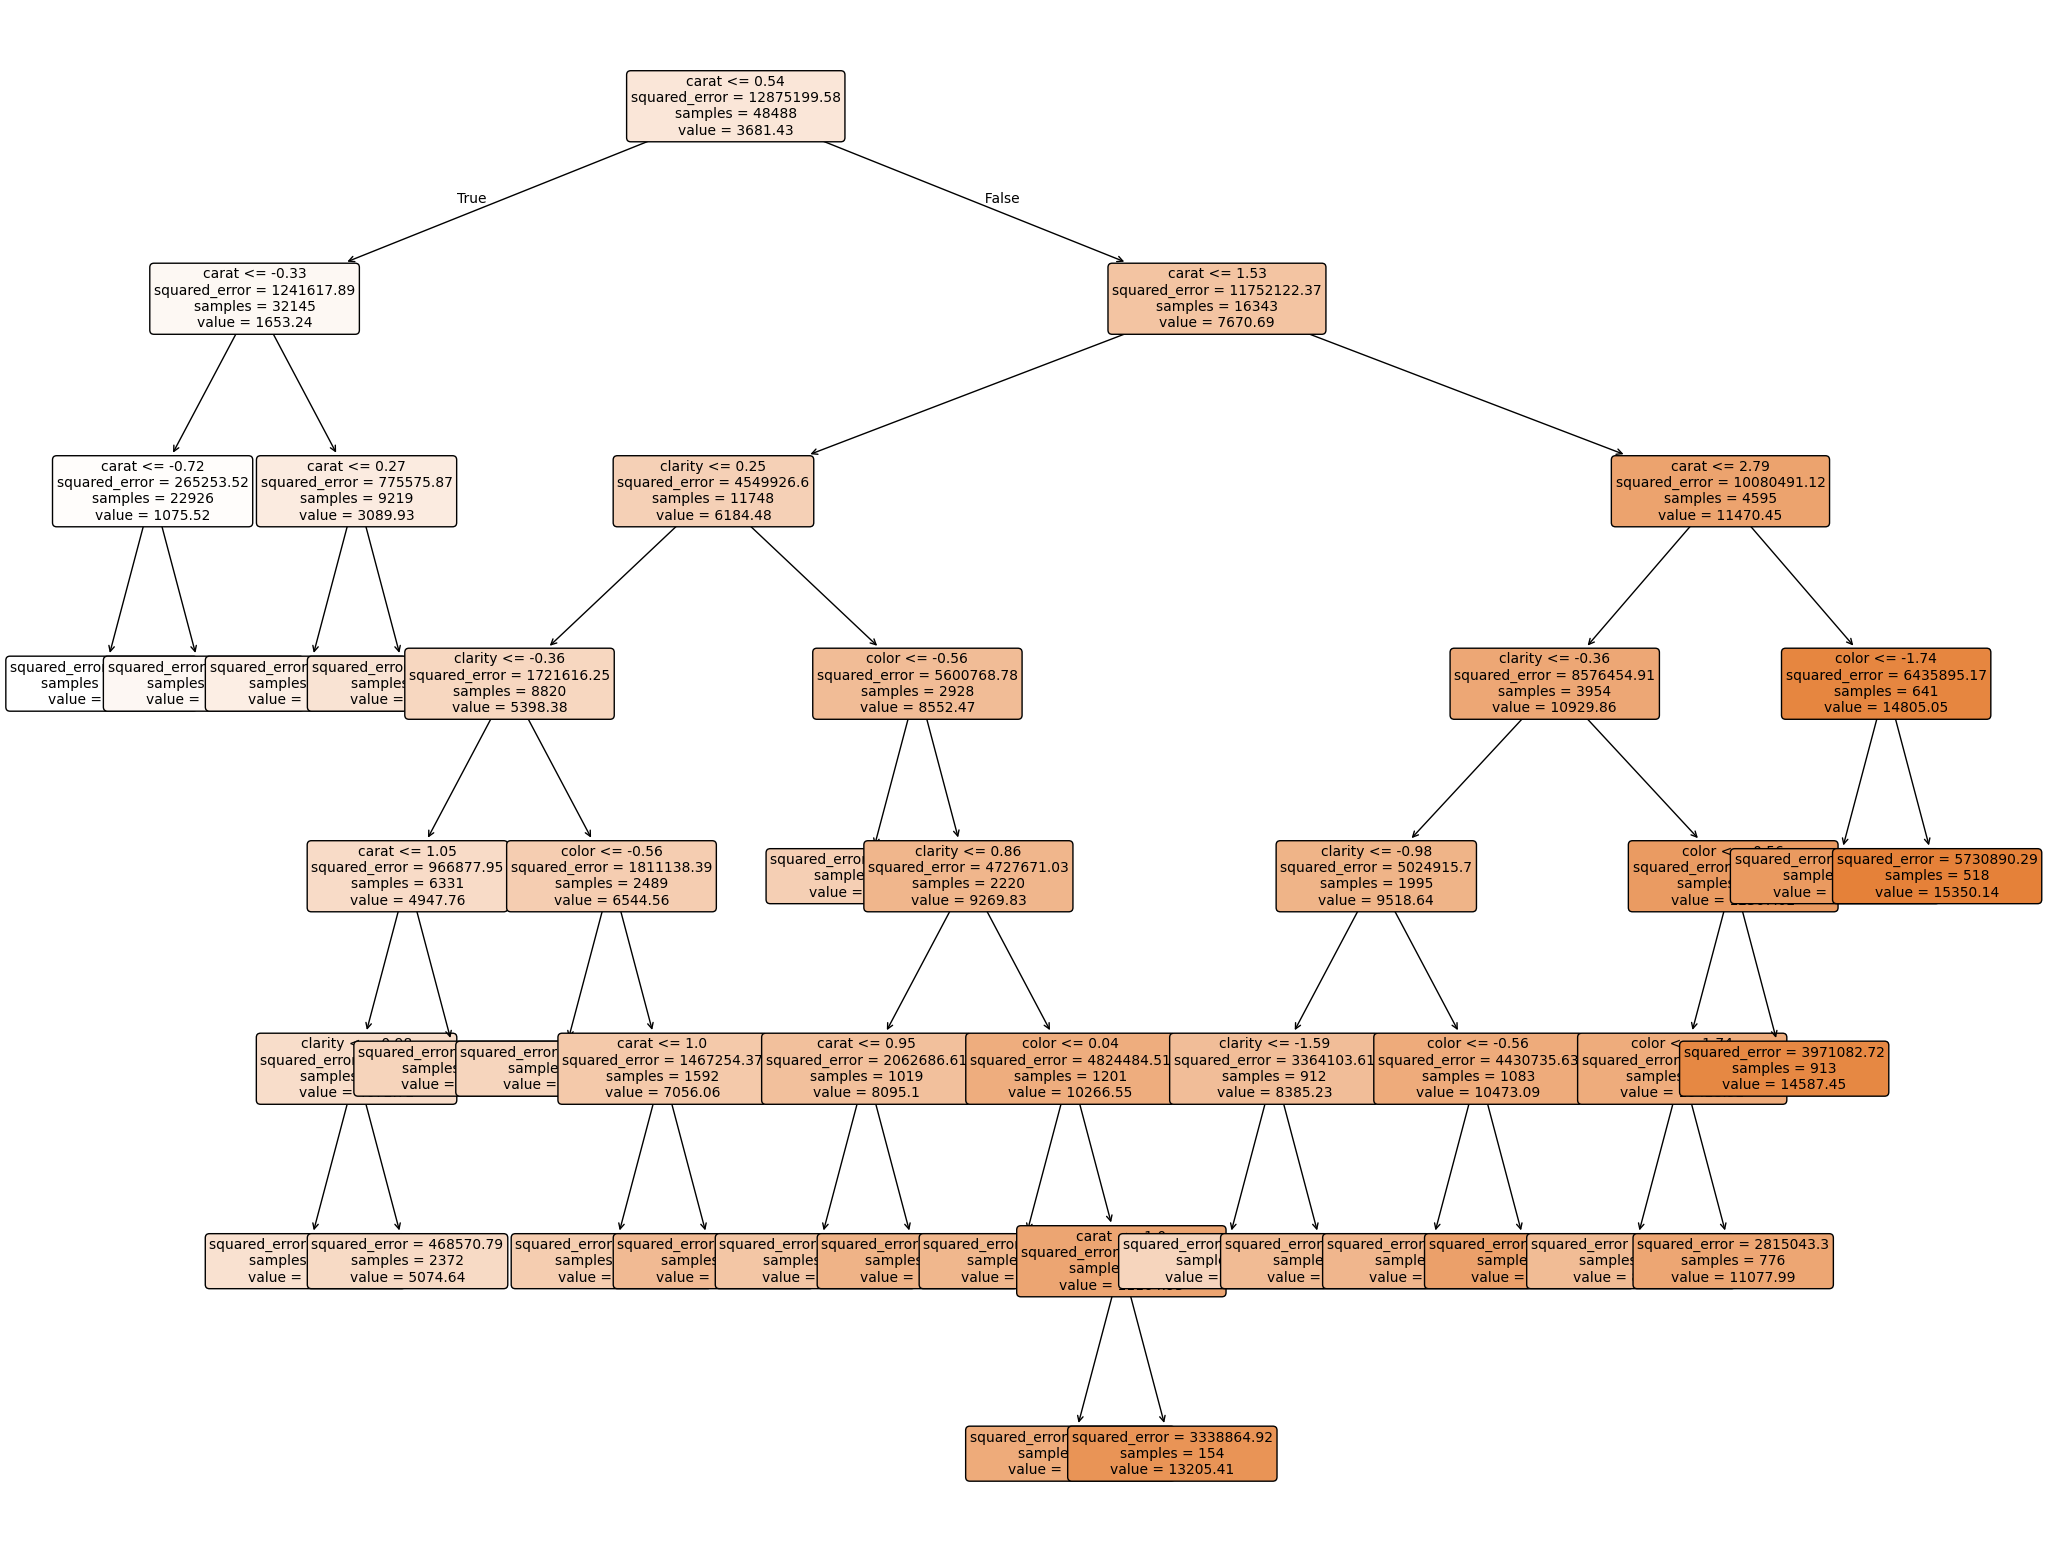

In [ ]:
final_model = best_pipeline.named_steps['dtr']

fig = plt.figure(figsize=(25, 20), facecolor='white')
ax = fig.add_subplot(111)

plot_tree(final_model, 
          feature_names=list(x.columns), 
          filled=True, 
          rounded=True, 
          precision=2, 
          fontsize=10,
          ax=ax)

plt.show()

### Вывод

В ходе выполнения работы была построена и оптимизирована модель регрессии на основе решающих деревьев. Использование фреймворка Optuna и метода кросс-валидации (`K`=5) позволило подобрать гиперпараметры, обеспечивающие высокую обобщающую способность. 

Модель объясняет 94.5% дисперсии целевого признака (согласно метрике $R^2$), что свидетельствует о высокой точности аппроксимации данных. Близость значений $R^2$ на кросс-валидации и на полной выборке (разница менее 0.1%) подтверждает устойчивость модели и отсутствие эффекта переобучения. 

Средняя относительная ошибка (`MAPE` = 18.7%) позволяет охарактеризовать качество прогнозирования как "хорошее".